<a href="https://colab.research.google.com/github/GMAC1231/Abdullah/blob/main/Sports_Car_Prices_Assignment%20Abdullah%20Muhammad%2022f23591.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Coding of the Decision Tree (DT) Algorithm in Python**

**Introduction**

The Decision Tree algorithm was implemented using Python programming language and the Scikit-learn machine learning library.

The steps in python are as follows:

- Load the necessary libraries
- Input the dataset
- Preprocess the data
- Implement the model
- Train the model
- Validate the model
- Implement on the test set
- Evaluate the model

**Importing Required Libraries**

The first step to import necessary Python libraries

In [129]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


from sklearn.preprocessing import LabelEncoder

| Library                | Purpose                                     |
| ---------------------- | ------------------------------------------- |
| pandas                 | Data handling and analysis                  |
| numpy                  | Numerical operations                        |
| train_test_split       | Splitting dataset into training and testing |
| DecisionTreeClassifier | Decision Tree model                         |
| accuracy_score         | Calculates model accuracy                   |
| classification_report  | Displays precision, recall, and F1-score    |
| confusion_matrix       | Shows prediction results                    |
| LabelEncoder           | Converts text data into numerical values    |


**Loading the Dataset**

The dataset uses the read_csv() function to load the data.

In [130]:


df = pd.read_csv('/content/Sport car price.csv')



print(df.head())

      Car Make Car Model  ...  0-60 MPH Time (seconds) Price (in USD)
0      Porsche       911  ...                        4        101,200
1  Lamborghini   Huracan  ...                      2.8        274,390
2      Ferrari   488 GTB  ...                        3        333,750
3         Audi        R8  ...                      3.2        142,700
4      McLaren      720S  ...                      2.7        298,000

[5 rows x 8 columns]


**Explanation**

read_csv() loads the dataset file.
head() displays the first five rows of the dataset.

**Checking the Dataset Information**

The dataset structure has been examined before preprocessing

In [131]:


print(df.info())



print(df.describe())


print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Car Make                 1007 non-null   object
 1   Car Model                1007 non-null   object
 2   Year                     1007 non-null   int64 
 3   Engine Size (L)          997 non-null    object
 4   Horsepower               1007 non-null   object
 5   Torque (lb-ft)           1004 non-null   object
 6   0-60 MPH Time (seconds)  1007 non-null   object
 7   Price (in USD)           1007 non-null   object
dtypes: int64(1), object(7)
memory usage: 63.1+ KB
None
              Year
count  1007.000000
mean   2021.201589
std       2.019802
min    1965.000000
25%    2021.000000
50%    2021.000000
75%    2022.000000
max    2023.000000
Car Make                    0
Car Model                   0
Year                        0
Engine Size (L)            10
Horsepower       

| Function       | Purpose                       |
| -------------- | ----------------------------- |
| info()         | Displays dataset structure    |
| describe()     | Shows statistical information |
| isnull().sum() | Counts missing values         |


**Handling the Missing Value**

Missing numerical values has been replaced by the median value

In [132]:
df['Horsepower'] = pd.to_numeric(df['Horsepower'], errors='coerce')
df['Engine Size (L)'] = pd.to_numeric(df['Engine Size (L)'], errors='coerce')

df['Horsepower'] = df['Horsepower'].fillna(df['Horsepower'].median())
df['Engine Size (L)'] = df['Engine Size (L)'].fillna(df['Engine Size (L)'].median())

**Explanation**

Median values were used because they are less affected by outliers.

**Label Encoding**

The Categorial data such as car make and the model has been converted into numercial value

In [133]:
le = LabelEncoder()
df['Car Make'] = le.fit_transform(df['Car Make'])
df['Car Model'] = le.fit_transform(df['Car Model'])

**Feature Selection**

The input features and target variable were selected.

In [134]:

df['Torque (lb-ft)'] = pd.to_numeric(
    df['Torque (lb-ft)'].astype(str).str.replace(',', '', regex=False).str.replace('+', '', regex=False),
    errors='coerce'
)

df['Torque (lb-ft)'] = df['Torque (lb-ft)'].fillna(df['Torque (lb-ft)'].median())


df['Price (in USD)'] = pd.to_numeric(
    df['Price (in USD)'].astype(str).str.replace(',', '', regex=False).str.replace('+', '', regex=False),
    errors='coerce'
)

df['Price (in USD)'] = df['Price (in USD)'].fillna(df['Price (in USD)'].median())

X = df[
    [
        'Car Make',
        'Car Model',
        'Year',
        'Engine Size (L)',
        'Horsepower',
        'Torque (lb-ft)'
    ]
]

y = df['Price (in USD)']

**Explanation**

The code is used for data preprocessing and preparation in a machine learning project for car price prediction. First, the Torque (lb-ft) column is converted into a numeric format by changing all values into strings and removing unwanted characters such as commas and plus signs. After cleaning the text values, the pd.to_numeric() function converts them into numerical data, while invalid values are replaced with NaN using errors='coerce'. Missing values in the torque column are then handled by replacing them with the median value of the column using the fillna() function. The same preprocessing steps are applied to the Price (in USD) column to ensure that all price values are numerical and that missing values are filled appropriately. After cleaning the dataset, the code selects important car features including car make, car model, year, engine size, horsepower, and torque as the input variables (X) for the machine learning model. Finally, the Price (in USD) column is assigned to y, which represents the target variable that the model will learn to predict.


## Categorizing 'Price (in USD)'

To use a classification model effectively, the continuous 'Price (in USD)' variable needs to be converted into discrete categories. This step will group prices into predefined ranges, transforming the problem into a multi-class classification task.

In [135]:

df['Price Category'] = pd.qcut(df['Price (in USD)'], q=5, labels=False, duplicates='drop')


y = df['Price Category']

print("Price Categories and their counts:")
print(df['Price Category'].value_counts())


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Price Categories and their counts:
Price Category
0    208
1    206
4    202
3    199
2    192
Name: count, dtype: int64


**Splitting the Dataset**

The dataset was divided into training and testing datasets.

In [136]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

| Parameter       | Purpose                     |
| --------------- | --------------------------- |
| test_size=0.2   | 20% testing data            |
| random_state=42 | Produces consistent results |


**Creating the Decision Tree**

The Decision Tree model was created using the Gini Criterion

In [137]:
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)

**Explanation**

In this code, DecisionTreeClassifier() is used to initialize a Decision Tree algorithm for classification tasks. The parameter criterion='gini' specifies that the model should use the Gini Impurity method to determine the best feature for splitting the data at each node of the tree. Gini Impurity measures how mixed the classes are in a node, and the algorithm selects splits that reduce impurity the most. The parameter max_depth=5 limits the maximum depth of the decision tree to 5 levels, which helps prevent overfitting by restricting the complexity of the model. Without this limit, the tree could become too large and memorize the training data instead of learning general patterns. The parameter random_state=42 ensures that the results are reproducible by fixing the random seed used during model training. This means the model will produce the same results each time the code is executed. Overall, this line creates a Decision Tree model configured to classify data using controlled tree depth and consistent random behavior.

**Training the Model**

The model was trained using the training dataset.

In [138]:
dt_model.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

**Explanation**

The model predicts the output class for unseen testing data.

**Making Predictions**

After training, predictions were generated using the testing dataset.

In [139]:
y_pred = dt_model.predict(X_test)

**Explanation**

The model predicts the output class for unseen testing data.

**Evaluating the Model**

The performance of the model was evaluated using several metrics.

In [140]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:",accuracy)

print(classification_report(y_test, y_pred))


Accuracy: 0.7920792079207921
              precision    recall  f1-score   support

           0       0.72      0.94      0.81        35
           1       0.81      0.73      0.77        48
           2       0.95      0.57      0.71        35
           3       0.72      0.71      0.72        41
           4       0.83      1.00      0.91        43

    accuracy                           0.79       202
   macro avg       0.81      0.79      0.78       202
weighted avg       0.81      0.79      0.79       202



| Metric           | Purpose                                 |
| ---------------- | --------------------------------------- |
| Accuracy         | Measures overall prediction correctness |
| Precision        | Measures correct positive predictions   |
| Recall           | Measures detection ability              |
| F1-score         | Balances precision and recall           |


**Visualizing the Decision Tree**

The trained Decision Tree was visualized using Scikit-learn plotting functions.

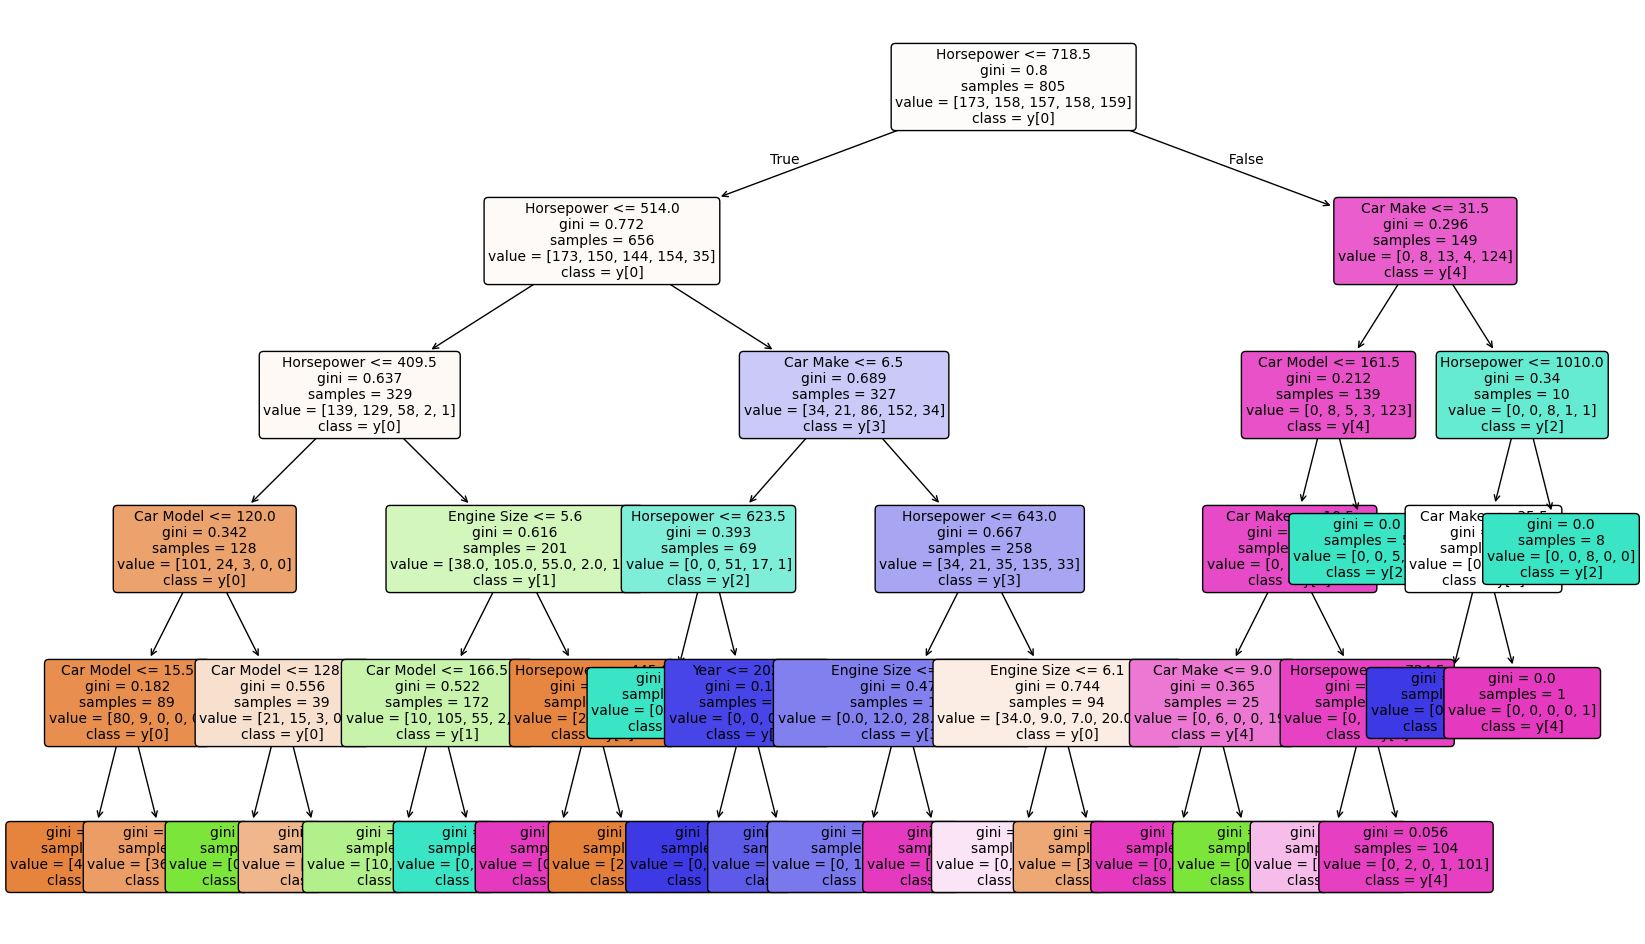

In [141]:




import matplotlib.pyplot as plt
from sklearn import tree


plt.figure(figsize=(20, 12))


tree.plot_tree(
    dt_model,
    feature_names=[
        'Car Make',
        'Car Model',
        'Year',
        'Engine Size',
        'Horsepower',
        'Torque'
    ],
    class_names=True,
    filled=True,
    rounded=True,
    fontsize=10
)


plt.show()

This code is used to visualize the trained Decision Tree model graphically. First, the matplotlib.pyplot library is imported to create and display plots, while tree is imported from Scikit-learn to access Decision Tree visualization functions. The line plt.figure(figsize=(20, 12)) creates a large figure window with a width of 20 inches and a height of 12 inches to ensure that the tree structure is displayed clearly and is easy to read. The tree.plot_tree() function is then used to draw the Decision Tree model stored in dt_model. The feature_names parameter provides the names of the input features used in the model, such as Car Make, Car Model, Year, Engine Size, Horsepower, and Torque, allowing each split in the tree to display the corresponding feature name. The parameter class_names=True enables the display of class labels in the leaf nodes of the tree. The filled=True option colors the nodes based on the predicted class, making the visualization easier to interpret. The rounded=True parameter creates rounded corners for the nodes to improve the appearance of the graph, while fontsize=10 controls the text size inside the nodes. Finally, plt.show() displays the complete Decision Tree visualization on the screen. This graphical representation helps in understanding how the Decision Tree algorithm makes decisions and classifies the data based on different feature conditions.

**Confusion Matrix**

<Figure size 800x600 with 0 Axes>

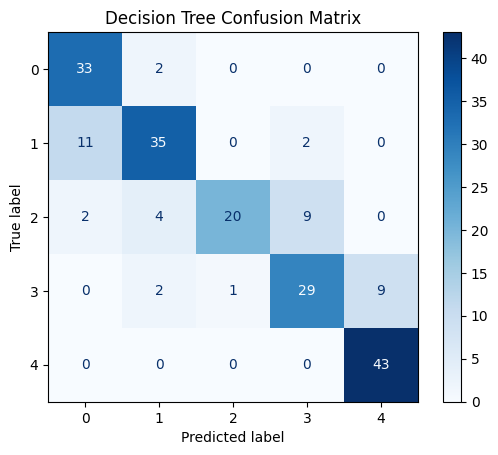

In [142]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


y_pred = dt_model.predict(X_test)


cm = confusion_matrix(y_test, y_pred)


disp = ConfusionMatrixDisplay(confusion_matrix=cm)

plt.figure(figsize=(8,6))

disp.plot(cmap='Blues')

plt.title("Decision Tree Confusion Matrix")

plt.show()

The confusion matrix is used to evaluate the performance of the Decision Tree classifier. It compares the actual class labels with the predicted class labels and shows how many predictions were correct and incorrect for each category. This helps in understanding the classification performance of the model.

**Correlation Heat Map**

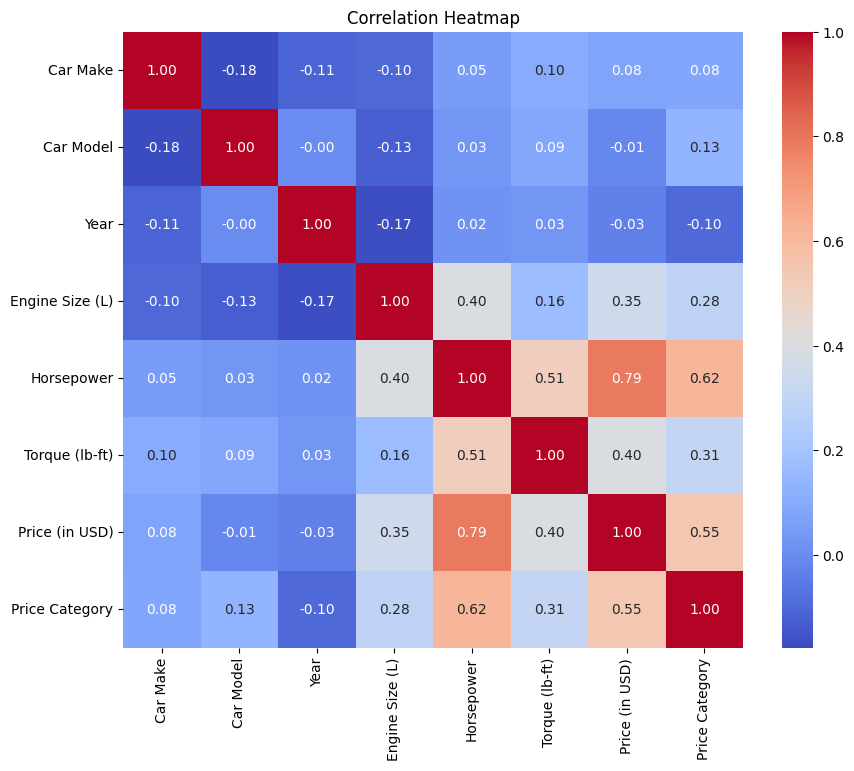

In [143]:


import seaborn as sns
import matplotlib.pyplot as plt


numeric_df = df.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()


plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.show()

The correlation heatmap visualizes the relationships between numerical variables in the dataset. Correlation values closer to 1 indicate a strong positive relationship, while values closer to -1 indicate a strong negative relationship. Values near 0 show weak or no relationship. This heatmap helps identify which features are strongly related to each other.

**Accuracy Graph**

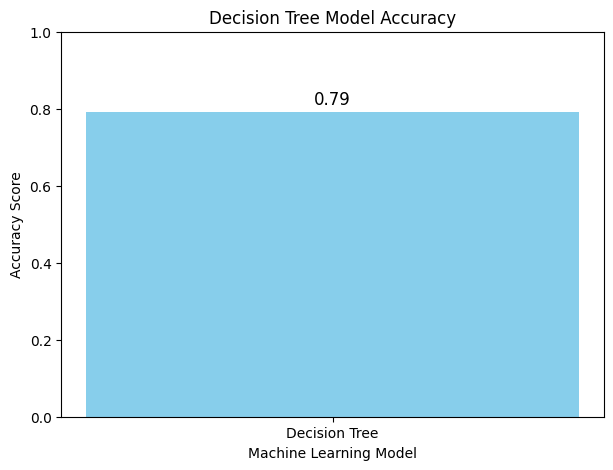

In [144]:




import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score


accuracy = accuracy_score(y_test, y_pred)


models = ['Decision Tree']
scores = [accuracy]


plt.figure(figsize=(7,5))


bars = plt.bar(models, scores, color='skyblue')


plt.ylim(0, 1)


plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy Score")
plt.title("Decision Tree Model Accuracy")


for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.02,
        round(yval, 2),
        ha='center',
        fontsize=12
    )


plt.show()

The accuracy graph visually represents the accuracy score of the Decision Tree model. Accuracy measures how many predictions were correctly classified out of the total predictions made by the model. Higher accuracy values indicate better model performance.